In [ ]:
import pandas as pd

In [ ]:
df=pd.read_csv("/content/fake_reviews_dataset.csv")

In [ ]:
df.head(5)

,category,rating,label,text_
0,Home_and_Kitchen_5,5.0,CG,"Love this! Well made, sturdy, and very comfor..."
1,Home_and_Kitchen_5,5.0,CG,"love it, a great upgrade from the original. I..."
2,Home_and_Kitchen_5,5.0,CG,This pillow saved my back. I love the look and...
3,Home_and_Kitchen_5,1.0,CG,"Missing information on how to use it, but it i..."
4,Home_and_Kitchen_5,5.0,CG,Very nice set. Good quality. We have had the s...


###Shape of the dataset

In [ ]:
print(f"Dataset shape: {df.shape}")

Dataset shape: (40432, 4)


### Missing values in each column

In [ ]:
print("Missing values per column:")
display(df.isnull().sum())

Missing values per column:


,0
category,0
rating,0
label,0
text_,0


###Check for duplicate reviews

In [ ]:
dup = df.duplicated(subset=['text_']).sum()
print(f"Number of duplicate reviews: {dup}")

Number of duplicate reviews: 20


###Class distribution

#### a) Product categories (multiclass)

In [ ]:
print("Distribution of Product Categories:")
display(df['category'].value_counts())

Distribution of Product Categories:


,count
category,
Kindle_Store_5,4730
Books_5,4370
Pet_Supplies_5,4254
Home_and_Kitchen_5,4056
Electronics_5,3988
Sports_and_Outdoors_5,3946
Tools_and_Home_Improvement_5,3858
Clothing_Shoes_and_Jewelry_5,3848
Toys_and_Games_5,3794


#### b) Review authenticity (fake vs genuine)

In [ ]:
print("Distribution of Review Authenticity Labels:")
display(df['label'].value_counts())

Distribution of Review Authenticity Labels:


,count
label,
CG,20216
OR,20216


###Brief comment on dataset characteristics

- **Dataset Size**: The dataset contains 40,432 entries and 4 columns.
- **Number of Classes**:
    - There are 5 distinct product categories, making it a multiclass classification scenario for categories.
    - For review authenticity, there are 2 classes ('CG' for computer-generated/fake and 'OR' for original/genuine).
- **Balance**:
    - The product categories appear to be relatively balanced, with each category having a similar number of entries (around 8,000).
    - The review authenticity labels (`label` column) are perfectly balanced, with 20,216 entries for 'CG' and 20,216 for 'OR'.

### Download necessary NLTK packages ('punkt', 'stopwords', 'wordnet') required for tokenization, stopword removal, and lemmatization.


In [ ]:
import nltk
nltk.download('punkt')
nltk.download('stopwords')
nltk.download('wordnet')

[nltk_data] Downloading package punkt to /root/nltk_data...
[nltk_data]   Package punkt is already up-to-date!
[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!
[nltk_data] Downloading package wordnet to /root/nltk_data...
[nltk_data]   Package wordnet is already up-to-date!


True

Now we create a new column named `clean_review` and begin the text preprocessing by applying initial cleaning steps such as converting text to lowercase, removing URLs, punctuation, numerical digits, and extra whitespace.



In [ ]:
import re
import string
from nltk.corpus import stopwords
from nltk.stem import WordNetLemmatizer
from nltk.tokenize import word_tokenize

def clean_text(text):
    text = text.lower()
    text = re.sub(r'https?://\S+|www\.\S+', '', text)
    text = text.translate(str.maketrans('', '', string.punctuation))
    text = re.sub(r'\d+', '', text)
    text = re.sub(r'\s+', ' ', text).strip()
    return text

df['clean_review'] = df['text_'].apply(clean_text)
print("Initial cleaning (lowercase, URL, punctuation, digit, whitespace removal) applied and 'clean_review' column created.")

Initial cleaning (lowercase, URL, punctuation, digit, whitespace removal) applied and 'clean_review' column created.


After the completion of initial cleaning we need to perform tokenization, stopword removal, and lemmatization on the `clean_review` column. For this task we need to first download `punkt_tab`





In [ ]:
import nltk
nltk.download('punkt_tab')

[nltk_data] Downloading package punkt_tab to /root/nltk_data...
[nltk_data]   Package punkt_tab is already up-to-date!


True

In [ ]:
stop_words = set(stopwords.words('english'))
lemmatizer = WordNetLemmatizer()

def process_text(text):
    tokens = word_tokenize(text)
    tokens = [word for word in tokens if word not in stop_words]
    lemmas = [lemmatizer.lemmatize(word) for word in tokens]
    return ' '.join(lemmas)

df['clean_review'] = df['clean_review'].apply(process_text)
print("Tokenization, stopword removal, and lemmatization applied to 'clean_review' column.")

Tokenization, stopword removal, and lemmatization applied to 'clean_review' column.


In [ ]:
print("Displaying original and cleaned reviews:")
display(df[['text_', 'clean_review']].head())

Displaying original and cleaned reviews:


,text_,clean_review
0,"Love this! Well made, sturdy, and very comfor...",love well made sturdy comfortable love itvery ...
1,"love it, a great upgrade from the original. I...",love great upgrade original ive mine couple year
2,This pillow saved my back. I love the look and...,pillow saved back love look feel pillow
3,"Missing information on how to use it, but it i...",missing information use great product price
4,Very nice set. Good quality. We have had the s...,nice set good quality set two month


### Before-and-After Examples


We randomly select 3 rows from the DataFrame and display both the original `text_` and the processed `clean_review` columns.



In [ ]:
print("Displaying before-and-after examples of review text (3 random samples):")
display(df[['text_', 'clean_review']].sample(3))

Displaying before-and-after examples of review text (3 random samples):


,text_,clean_review
7158,Construction is ok. Another chinazon company ...,construction ok another chinazon company half ...
779,Have dishes with this pattern and love the gla...,dish pattern love glass match love size shape
8353,When you zoom in all the way you can see the h...,zoom way see hood photo


### Why Text Preprocessing is Crucial for NLP Models

Text preprocessing is a crucial step in any Natural Language Processing (NLP) pipeline. It converts raw, unstructured text into a clean and standardized format that NLP models can process effectively. Without preprocessing, inconsistencies and irrelevant information in text can degrade model performance and increase computational cost.

A major goal of preprocessing is noise reduction. Raw text often contains irrelevant elements such as symbols, HTML tags, URLs, numbers, extra whitespace, and common stopwords like the or is. Removing this noise helps the model focus on meaningful words, leading to better feature extraction and more efficient learning.

Preprocessing also ensures standardization. Since words can appear in different forms or cases (e.g., run, running, ran), techniques like lowercasing, punctuation removal, stemming, and lemmatization treat similar words as a single entity. This reduces vocabulary size and prevents the model from learning redundant or misleading features.

Overall, effective preprocessing results in improved model performance and reduced dimensionality. Cleaner and more consistent data allows models to learn robust patterns, generalize better, and operate efficiently, especially on large text datasets.

## Task 1: Product Category Classification

*   Using the vectorized review representations:
*   Train a multiclass classification model to predict the product category of a given review.
*   Evaluate the model using appropriate performance metrics (e.g., accuracy, precision, recall, F1-score).

In [77]:
from sklearn.feature_extraction.text import TfidfVectorizer

# Initialize TF-IDF Vectorizer
tfidf_vectorizer = TfidfVectorizer(max_features=5000) # Limiting to 5000 features for manageable size

# Fit and transform the 'clean_review' column
X = tfidf_vectorizer.fit_transform(df['clean_review'])

print("TF-IDF vectorization complete. Shape of X:", X.shape)

TF-IDF vectorization complete. Shape of X: (40432, 5000)


In [82]:
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report, accuracy_score

y_category = df['category']

X_train, X_test, y_train, y_test = train_test_split(
    X, y_category, test_size=0.2, random_state=42, stratify=y_category
)

category_model = LogisticRegression(max_iter=1000, n_jobs=-1)
category_model.fit(X_train, y_train)

y_pred_cat = category_model.predict(X_test)

print("Category Classification Accuracy:", accuracy_score(y_test, y_pred_cat))
print(classification_report(y_test, y_pred_cat))

Category Classification Accuracy: 0.7755657227649314
                              precision    recall  f1-score   support

                     Books_5       0.73      0.76      0.74       874
Clothing_Shoes_and_Jewelry_5       0.79      0.80      0.80       770
               Electronics_5       0.80      0.80      0.80       798
          Home_and_Kitchen_5       0.70      0.74      0.72       811
              Kindle_Store_5       0.79      0.75      0.77       946
             Movies_and_TV_5       0.93      0.88      0.90       717
              Pet_Supplies_5       0.91      0.84      0.87       851
       Sports_and_Outdoors_5       0.63      0.66      0.64       789
Tools_and_Home_Improvement_5       0.69      0.72      0.70       772
            Toys_and_Games_5       0.83      0.84      0.83       759

                    accuracy                           0.78      8087
                   macro avg       0.78      0.78      0.78      8087
                weighted avg       

In [79]:
!pip install torch torchvision

In [80]:
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import TensorDataset, DataLoader

In [83]:
X_dense = X.toarray()
X_tensor = torch.tensor(X_dense, dtype=torch.float32)
y_tensor = torch.tensor(y_label.values, dtype=torch.float32)


from sklearn.model_selection import train_test_split

X_train_t, X_test_t, y_train_t, y_test_t = train_test_split(
    X_tensor, y_tensor, test_size=0.2, random_state=42, stratify=y_label
)

train_dataset = TensorDataset(X_train_t, y_train_t)
test_dataset = TensorDataset(X_test_t, y_test_t)

train_loader = DataLoader(train_dataset, batch_size=64, shuffle=True)
test_loader = DataLoader(test_dataset, batch_size=64)

In [84]:
class FakeReviewNN(nn.Module):
    def __init__(self, input_dim):
        super(FakeReviewNN, self).__init__()
        self.fc1 = nn.Linear(input_dim, 256)
        self.relu = nn.ReLU()
        self.fc2 = nn.Linear(256, 64)
        self.fc3 = nn.Linear(64, 1)
        self.sigmoid = nn.Sigmoid()

    def forward(self, x):
        x = self.fc1(x)
        x = self.relu(x)
        x = self.fc2(x)
        x = self.relu(x)
        x = self.fc3(x)
        x = self.sigmoid(x)
        return x

input_dim = X_tensor.shape[1]
model = FakeReviewNN(input_dim)

In [85]:
criterion = nn.BCELoss()
optimizer = optim.Adam(model.parameters(), lr=0.001)

In [90]:
epochs = 5

for epoch in range(epochs):
    model.train()
    total_loss = 0
    for X_batch, y_batch in train_loader:
        optimizer.zero_grad()
        outputs = model(X_batch).squeeze()
        loss = criterion(outputs, y_batch)
        loss.backward()
        optimizer.step()
        total_loss += loss.item()
    print(f"Epoch {epoch+1}/{epochs}, Loss: {total_loss/len(train_loader):.4f}")

Epoch 1/5, Loss: 0.0771
Epoch 2/5, Loss: 0.0377
Epoch 3/5, Loss: 0.0163
Epoch 4/5, Loss: 0.0064
Epoch 5/5, Loss: 0.0028


In [92]:
model.eval()
y_preds = []
y_true = []

with torch.no_grad():
    for X_batch, y_batch in test_loader:
        outputs = model(X_batch).squeeze()
        preds = (outputs >= 0.5).float()
        y_preds.extend(preds.tolist())
        y_true.extend(y_batch.tolist())

from sklearn.metrics import classification_report, accuracy_score

print("Neural Network Fake Review Detection Accuracy:", accuracy_score(y_true, y_preds))
print(classification_report(y_true, y_preds))

Neural Network Fake Review Detection Accuracy: 0.8709039198713986
              precision    recall  f1-score   support

         0.0       0.87      0.87      0.87      4044
         1.0       0.87      0.88      0.87      4043

    accuracy                           0.87      8087
   macro avg       0.87      0.87      0.87      8087
weighted avg       0.87      0.87      0.87      8087



In [88]:
model.eval()
y_preds = []
y_true = []

with torch.no_grad():
    for X_batch, y_batch in test_loader:
        outputs = model(X_batch).squeeze()
        preds = (outputs >= 0.5).float()
        y_preds.extend(preds.tolist())
        y_true.extend(y_batch.tolist())

from sklearn.metrics import classification_report, accuracy_score

print("Neural Network Fake Review Detection Accuracy:", accuracy_score(y_true, y_preds))
print(classification_report(y_true, y_preds))

Neural Network Fake Review Detection Accuracy: 0.8736243353530357
              precision    recall  f1-score   support

         0.0       0.85      0.90      0.88      4044
         1.0       0.90      0.85      0.87      4043

    accuracy                           0.87      8087
   macro avg       0.87      0.87      0.87      8087
weighted avg       0.87      0.87      0.87      8087



#Task 3: Word Cloud Generation

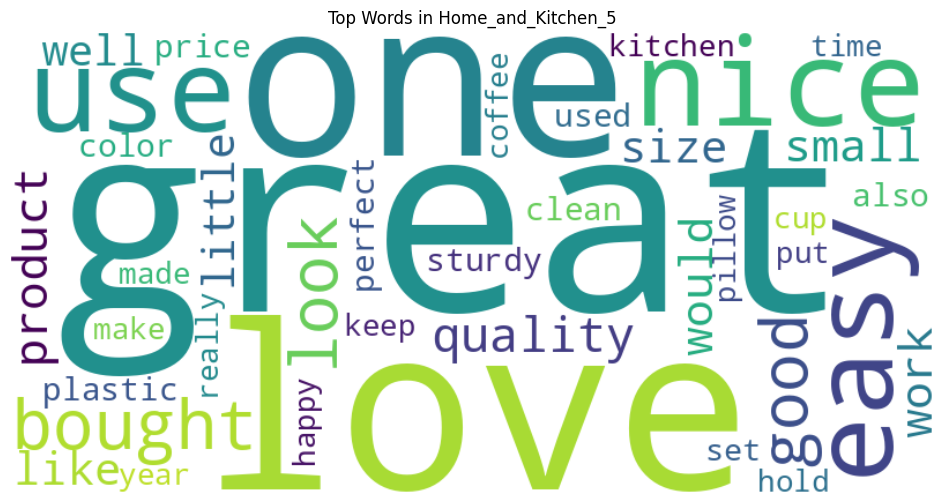

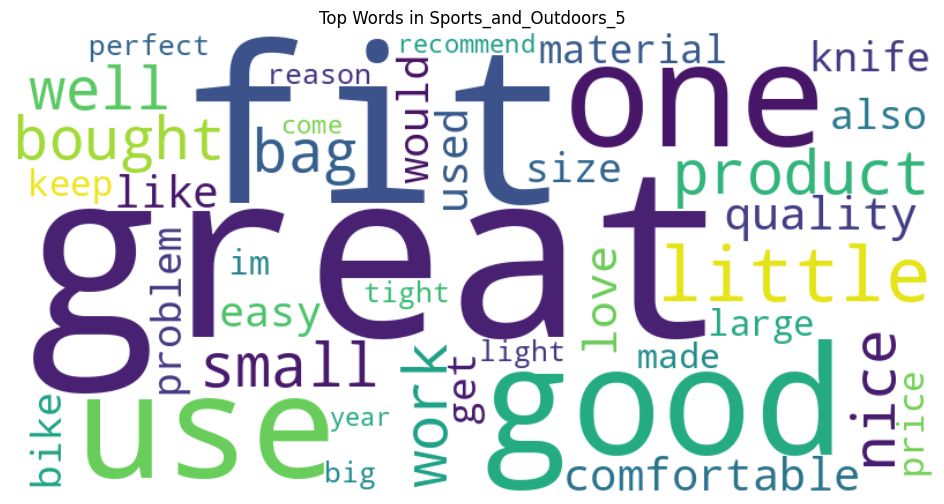

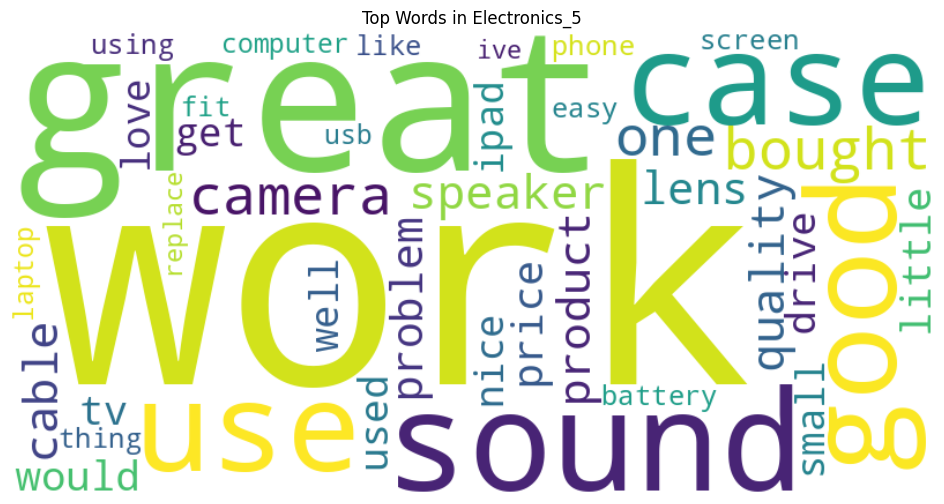

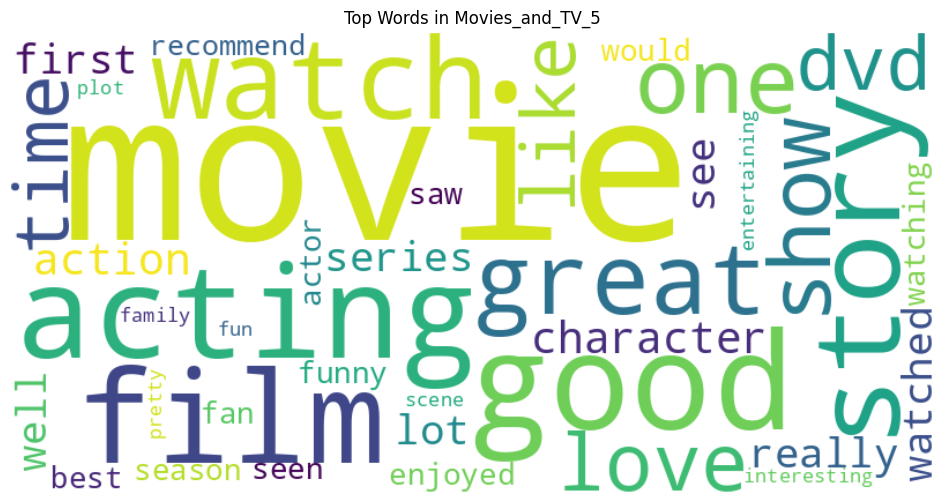

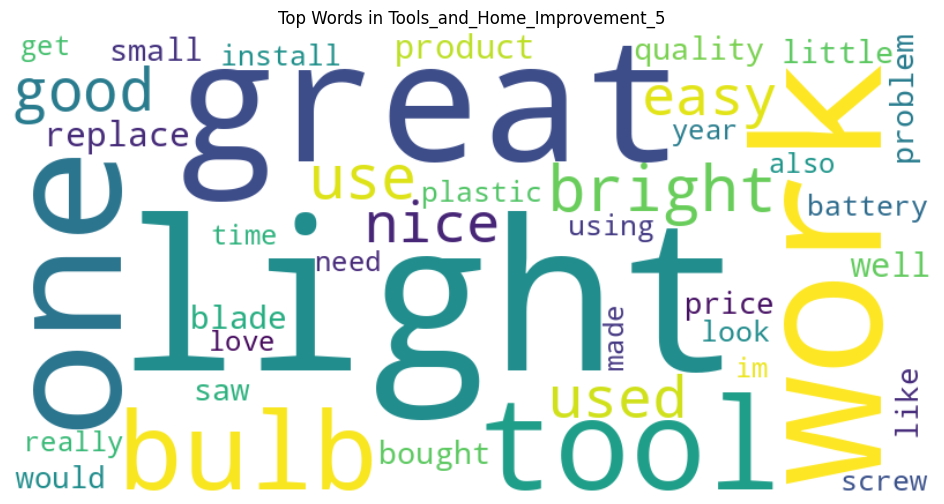

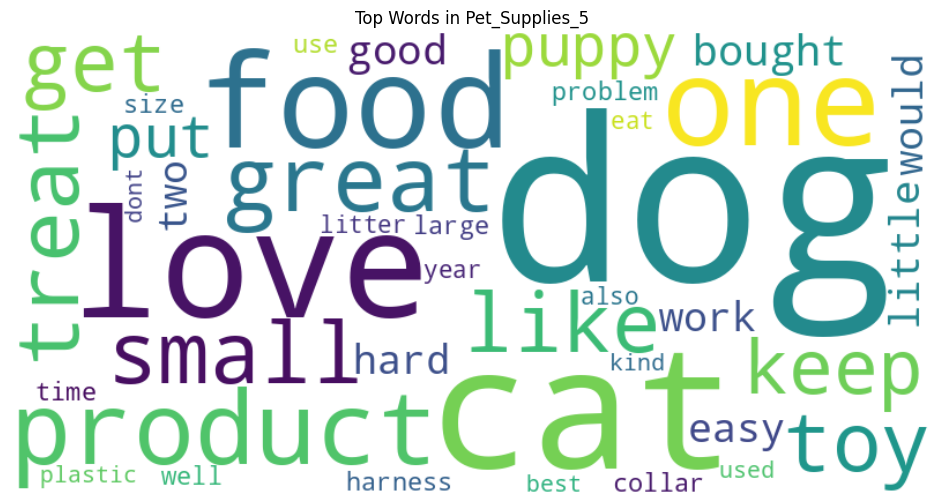

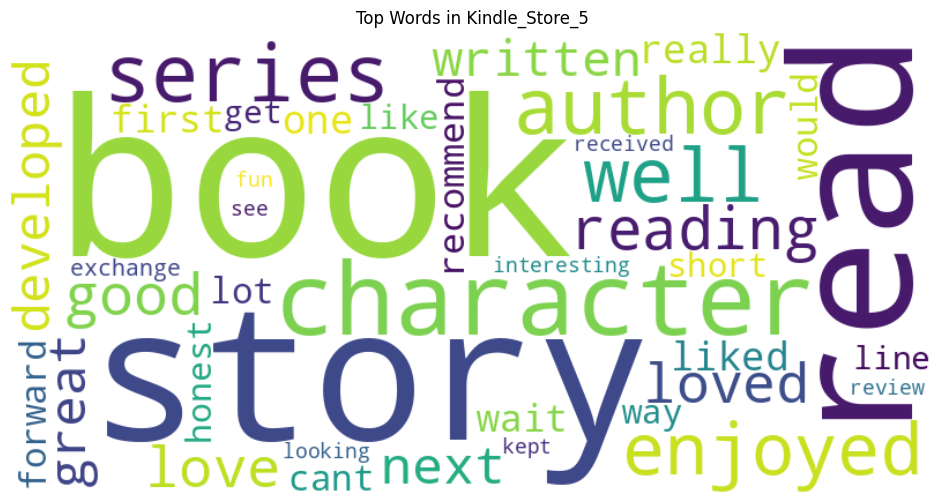

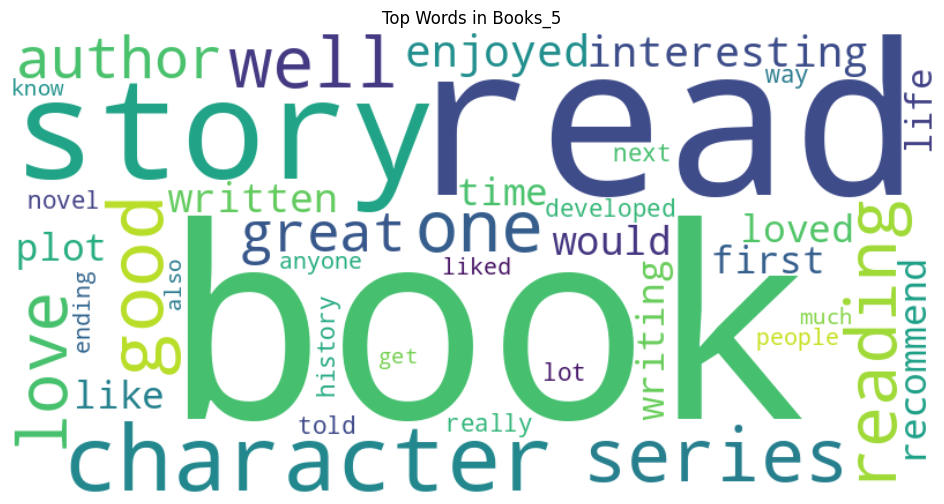

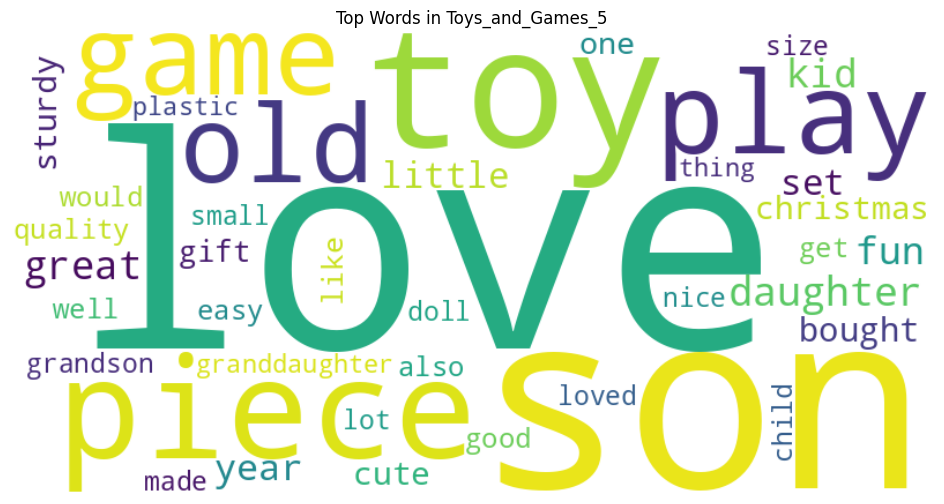

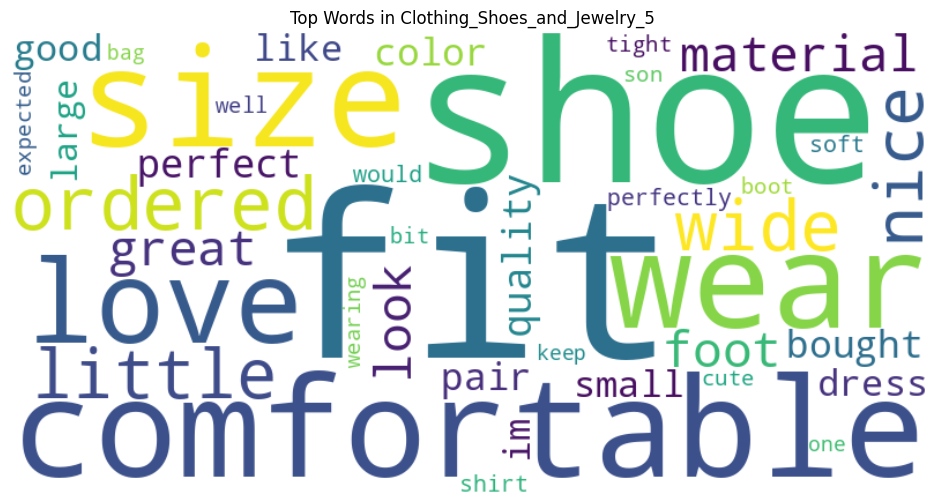

In [93]:
import matplotlib.pyplot as plt
from wordcloud import WordCloud
import numpy as np
import pandas as pd

categories = df['category'].unique()
feature_names = tfidf_vectorizer.get_feature_names_out() # Changed 'vectorizer' to 'tfidf_vectorizer'

for cat in categories:
    cat_indices = df[df['category'] == cat].index
    X_cat = X[cat_indices].toarray()
    avg_tfidf = np.mean(X_cat, axis=0)
    top_n = 40
    top_indices = avg_tfidf.argsort()[-top_n:]
    top_words = {feature_names[i]: avg_tfidf[i] for i in top_indices}

    wc = WordCloud(width=800, height=400, background_color='white')
    wc.generate_from_frequencies(top_words)

    plt.figure(figsize=(12,6))
    plt.imshow(wc, interpolation='bilinear')
    plt.axis('off')
    plt.title(f"Top Words in {cat}")
    plt.show()